# Linear Regression — Step by Step

This notebook builds a Linear Regression from scratch using **scikit-learn**, on the classic **Built-in Diabetes Dataset from scikit learn**.

**Steps covered:**
1. Load and explore the dataset
2. Check missing values and data types


*   EDA


3. Split into training and testing sets
4. Train a Linear Regression model
5. Predict target values
6. Evaluate the model using MAE, MSE, RMSE, and R² Score
7. Analyze model coefficients and intercept
8. Visualize Actual vs Predicted values
9. Predict the target for a new sample


## Step 1: Import Libraries

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline


## Step 2: Load the Dataset

We use the **Diabetes Dataset** — 422 total rows and 11 columns.

In [17]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data,columns=diabetes.feature_names)
y = diabetes.target
df = X.copy()
df['Target'] = y
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Step 3: Explore the Data

In [18]:
print("Total Number of rows:",df.shape[0])
print("Total Number of columns:",df.shape[1])
df.describe()

Total Number of rows: 442
Total Number of columns: 11


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## EDA Part 1 : Target Variable Distribution

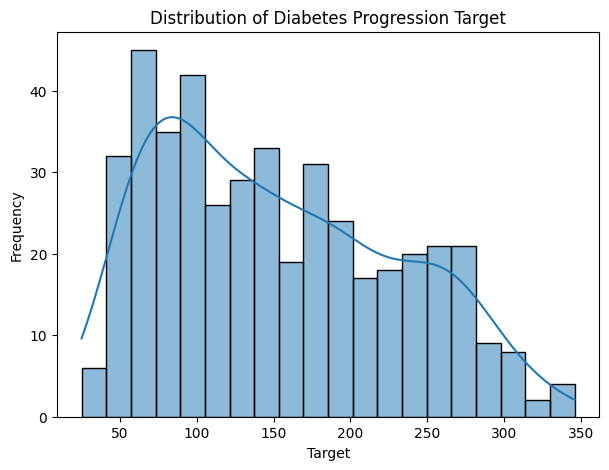

In [30]:
plt.figure(figsize=(7,5))

sns.histplot(y, bins=20, kde=True)

plt.title("Distribution of Diabetes Progression Target")

plt.xlabel("Target")

plt.ylabel("Frequency")

plt.show()

EDA Part 2: Correlation Heatmap

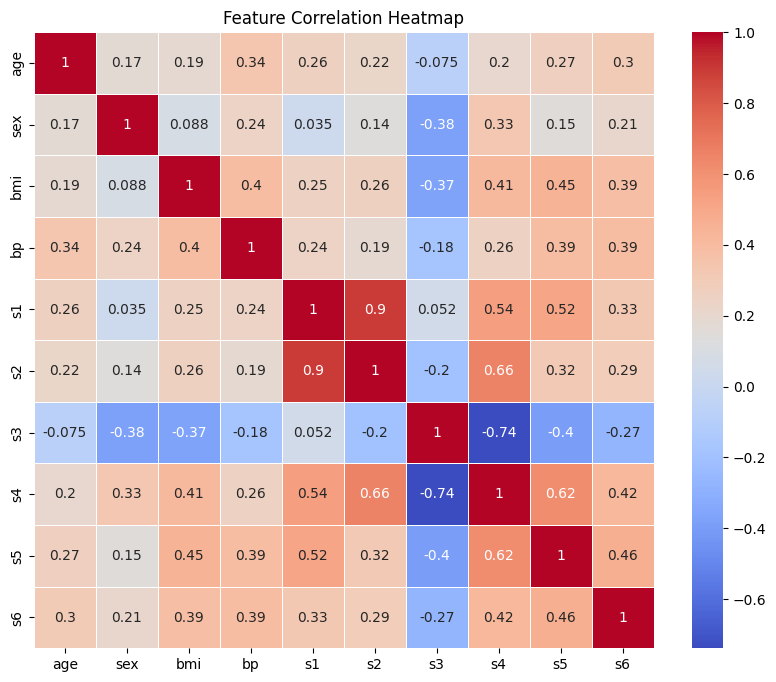

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(X.corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

EDA Part 3: BMI VS Target

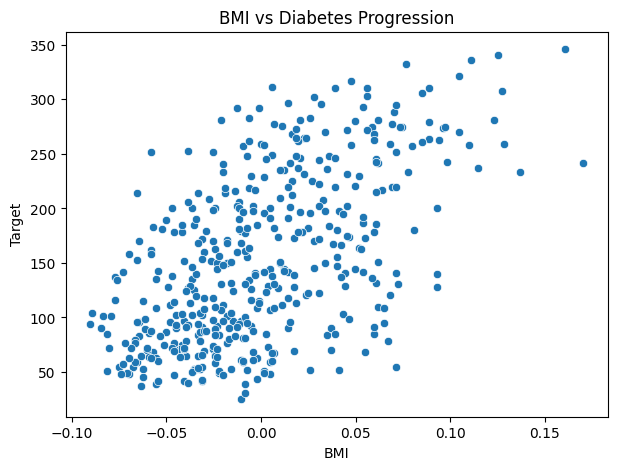

In [32]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X["bmi"],
    y=y
)

plt.title("BMI vs Diabetes Progression")

plt.xlabel("BMI")

plt.ylabel("Target")

plt.show()

## Step 4: Train/Test Split

We hold out 20% of the data for testing so we can check how well the tree generalizes.

In [19]:
X = df.drop('Target',axis=1)
y = df['Target']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 353
Test size : 89


## Step 5: Train Linear Regression Model

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Step 6: Make Prediction

In [23]:
y_pred = model.predict(X_test)

## Step 7: Evaluate model performance

In [24]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))


MAE : 42.79409467959994
MSE : 2900.1936284934814
RMSE : 53.85344583676593
R2 Score : 0.4526027629719195


## Step 8: Examine Model Coefficient

In [25]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef


,Feature,Coefficient
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


## Intercept

In [26]:
print(model.intercept_)

151.34560453985995


## Step 9: Visualize actual VS predicted

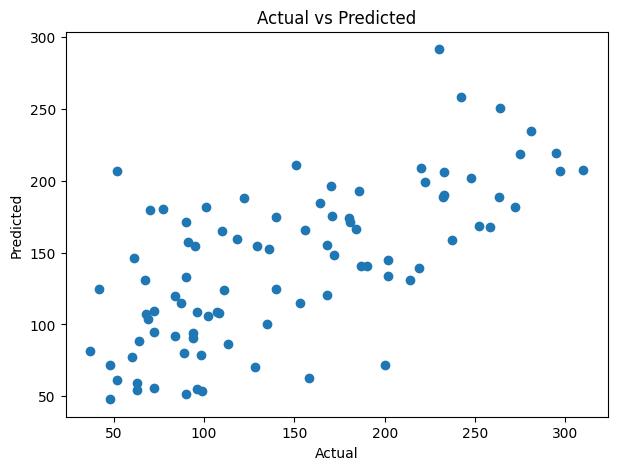

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

## Step 10: Predict a new sample.

In [29]:
new_sample = [X.iloc[0]]

prediction = model.predict(new_sample)

print("Predicted Target:", prediction)

Predicted Target: [210.74209145]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Summary
1. We trained a Linear Regression model using scikit-learn on the built-in Diabetes dataset to predict a continuous target value.
2. The model learned the relationship between the input features and the target by finding the best-fit line that minimizes prediction errors.
3. We evaluated the model using MAE, MSE, RMSE, and R² Score to measure prediction accuracy and overall performance.
4. The model coefficients showed how each feature influences the prediction, while the Actual vs Predicted plot helped visualize how well the model fits the data.
### Try next
1. Swap load_diabetes() with fetch_california_housing() or make_regression() (available in scikit-learn) to practice on different regression datasets.
2. Compare Linear Regression with Polynomial Regression to see how a non-linear model can improve predictions for curved relationships.